In [1]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dealroom = pd.read_csv('correct_funding_predictions.csv')
female_info = dealroom[dealroom['Gender']=='female']
male_info = dealroom[dealroom['Gender']=='male']

In [3]:
#female
stats_female = female_info.describe()
pd.options.display.float_format = '{:.3f}'.format
display(stats_female)

,Predicted Funding
count,90.000
mean,44985591.289
std,67057601.630
min,-9378936.000
25%,7848842.000
50%,22541273.000
75%,37393146.500
max,224762967.000


In [4]:
#male
stats_male = male_info.describe()
pd.options.display.float_format = '{:.3f}'.format
display(stats_male)

,Predicted Funding
count,261.000
mean,47666520.874
std,55261175.578
min,-6064085.000
25%,11163694.000
50%,27226158.000
75%,47099520.000
max,228077818.000


In [5]:
#difference male vs female
difference = stats_male['Predicted Funding'] - stats_female['Predicted Funding']
display(difference)

count         171.000
mean      2680929.585
std     -11796426.052
min       3314851.000
25%       3314852.000
50%       4684885.000
75%       9706373.500
max       3314851.000
Name: Predicted Funding, dtype: float64

Text(0.5, 1.0, 'Predicted funding (men vs women)')

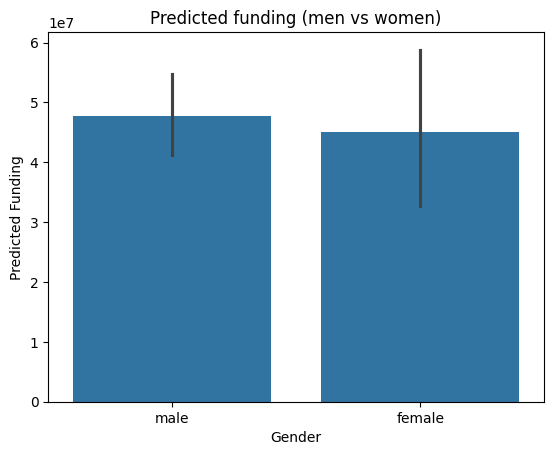

In [6]:
#plots
#men vs women funding 
gender_funding = sns.barplot(data=dealroom, x='Gender',y='Predicted Funding')
gender_funding.set_title('Predicted funding (men vs women)')

Text(0.5, 1.0, 'Predicted funding per each industry by gender')

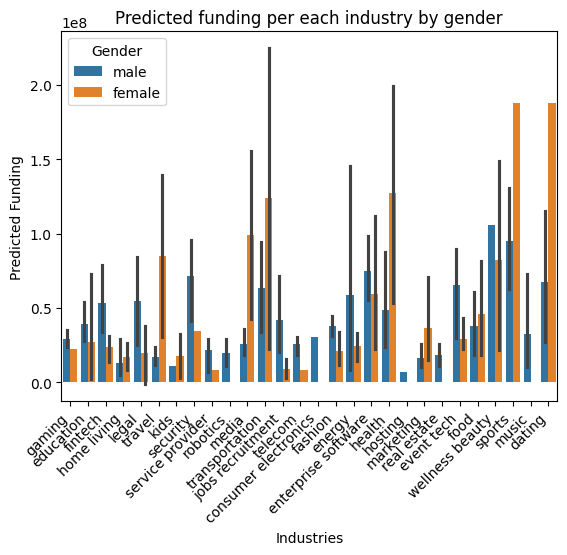

In [7]:
#Fudning by industry and gender
data = dealroom
#convert industries to a list
data['Industries'] = data['Industries'].apply(eval)
#transform industry column, to make separate rows for each industry 
data = data.explode('Industries')
sns.barplot(data = data, y='Predicted Funding', x ='Industries', hue='Gender')
plt.xticks(rotation=45, ha='right')
plt.title('Predicted funding per each industry by gender')

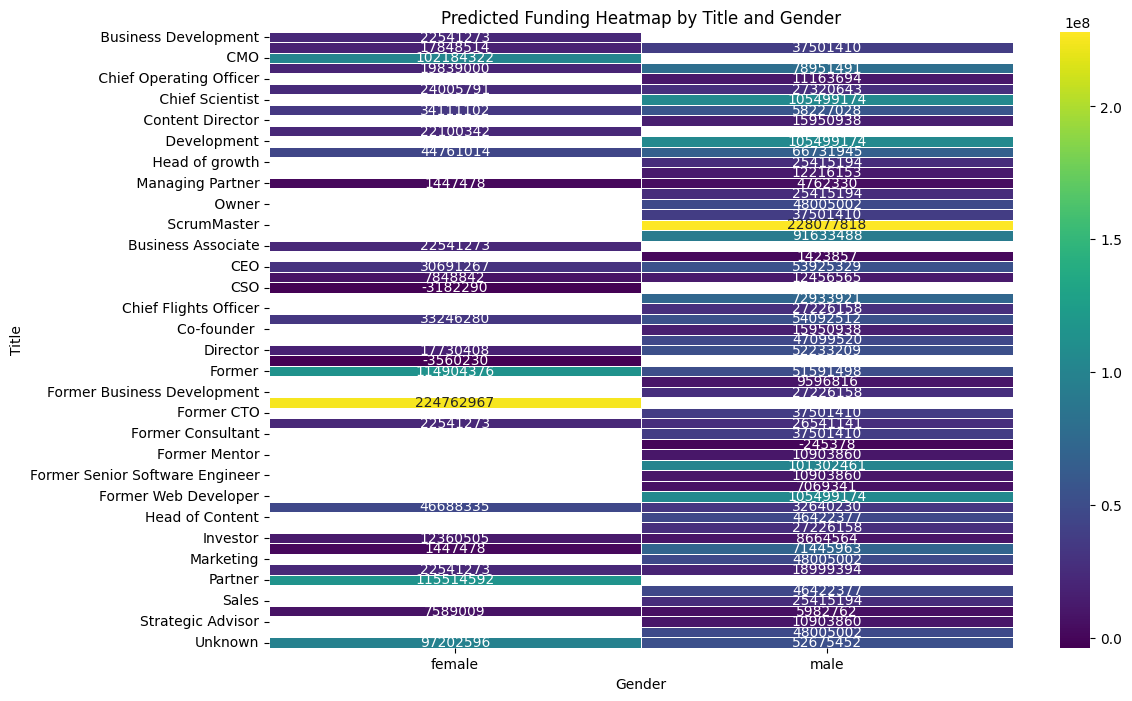

In [9]:

# Assuming 'title_data' is your DataFrame
plt.figure(figsize=(12, 8))
heatmap_data = title_data.pivot_table(index='Title', columns='Gender', values='Predicted Funding', aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.0f', linewidths=0.5)
plt.title('Predicted Funding Heatmap by Title and Gender')
plt.show()


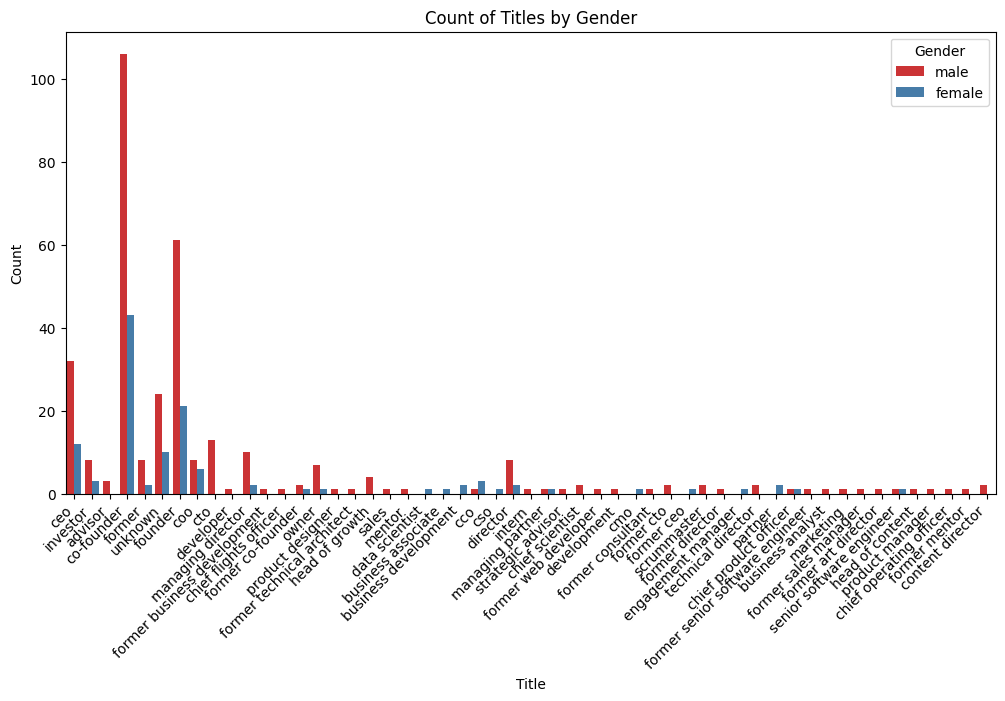

In [12]:
# Remove leading/trailing whitespaces
title_data['Title'] = title_data['Title'].str.strip()  
# Convert titles to lowercase 
title_data['Title'] = title_data['Title'].str.lower()
plt.figure(figsize=(12, 6))
sns.countplot(data=title_data, x='Title', hue='Gender', palette='Set1')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.title('Count of Titles by Gender')
plt.xlabel('Title')
plt.ylabel('Count')
plt.show()
